In [4]:
!pip install polars duckdb pyarrow matplotlib seaborn

In [5]:
import polars as pl
import duckdb
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
reviews_path = "Automotive.jsonl"
metadata_path = "meta_Automotive.jsonl"

In [7]:
reviews = pl.scan_ndjson("Automotive.jsonl")

metadata = pl.scan_ndjson("meta_Automotive.jsonl")

In [8]:
print(reviews.collect_schema())

Schema({'rating': Float64, 'title': String, 'text': String, 'images': List(Struct({'small_image_url': String, 'medium_image_url': String, 'large_image_url': String, 'attachment_type': String})), 'asin': String, 'parent_asin': String, 'user_id': String, 'timestamp': Int64, 'helpful_vote': Int64, 'verified_purchase': Boolean})


In [9]:
print(metadata.collect_schema())

Schema({'main_category': String, 'title': String, 'average_rating': Float64, 'rating_number': Int64, 'features': List(String), 'description': List(String), 'price': Float64, 'images': List(Struct({'thumb': String, 'large': String, 'variant': String, 'hi_res': String})), 'videos': List(Struct({'title': String, 'url': String, 'user_id': String})), 'store': String, 'categories': List(String), 'details': Struct({'Material': String, 'Fastener Type': String, 'Exterior': String, 'Color': String, 'Metal Type': String, 'Drive System': String, 'Brand': String, 'Inside Thread Size': String, 'Size': String, 'Manufacturer': String, 'Item Weight': String, 'Package Dimensions': String, 'Item model number': String, 'Is Discontinued By Manufacturer': String, 'Manufacturer Part Number': String, 'Date First Available': String, 'Product Dimensions': String, 'Special Features': String, 'Best Sellers Rank': Struct({'Automotive': Int64, 'Automotive Replacement Brake Caliper Brackets': Int64, 'Trunk Organizer

In [10]:
metadata_clean = metadata.select([

    "parent_asin",
    "title",
    "average_rating",
    "rating_number",
    "price",
    "store",
    "categories"

])

In [11]:
meta_df = metadata_clean.limit(50000).collect().to_pandas()

In [12]:
meta_df.head()

,parent_asin,title,average_rating,rating_number,price,store,categories
0,B00J9I1BD4,Caltric 3 Pack Oil Filter Compatible with Suzu...,5.0,1,13.00,Caltric,"[Automotive, Motorcycle & Powersports, Parts, ..."
1,B076PZ9X5R,APL 24 14x1.5 Acorn Spline Wheel Lug Nuts Blac...,4.4,59,NaN,APL,"[Automotive, Tires & Wheels, Accessories & Par..."
2,B00CMEHS34,Vent Cap,5.0,2,NaN,Unknown,[]
3,B09MWGTYL3,OkuTech Black Retractable Cargo Cover Rear Car...,3.0,1,139.99,OkuTech,"[Automotive, Interior Accessories, Consoles & ..."
4,B009EJV2Y6,Cardone Service Plus 14-1090 Remanufactured Ca...,4.8,5,35.76,Amazon Renewed,"[Automotive, Replacement Parts, Brake System, ..."


In [13]:
metadata_clean = metadata.select([

    "main_category",
    "title",
    "average_rating",
    "rating_number",
    "features",
    "description",
    "price",
    "images",
    "videos",
    "store",
    "categories",
    "details",
    "parent_asin",
    "bought_together"

])


In [14]:
meta_df = metadata_clean.limit(50000).collect().to_pandas()

In [15]:
meta_df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Automotive,Caltric 3 Pack Oil Filter Compatible with Suzu...,5.0,1,[],[Compatible with Suzuki modelsGSX1100E 1100 19...,13.00,[{'thumb': 'https://m.media-amazon.com/images/...,[],Caltric,"[Automotive, Motorcycle & Powersports, Parts, ...","{'Material': None, 'Fastener Type': None, 'Ext...",B00J9I1BD4,None
1,Automotive,APL 24 14x1.5 Acorn Spline Wheel Lug Nuts Blac...,4.4,59,"[Note: Fit for aftermarket wheels only, not fi...","[Type : Long Spline, Closed End Thread Pitch ...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],APL,"[Automotive, Tires & Wheels, Accessories & Par...","{'Material': 'Steel', 'Fastener Type': 'Lock',...",B076PZ9X5R,None
2,Automotive,Vent Cap,5.0,2,[],[030156-40 Features: -Use for power unit canis...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Unknown,[],"{'Material': None, 'Fastener Type': None, 'Ext...",B00CMEHS34,None
3,Automotive,OkuTech Black Retractable Cargo Cover Rear Car...,3.0,1,[Black Retractable SUV Cargo Security Shade Co...,"[Product Details:, Fits Car Model: Dodge Journ...",139.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],OkuTech,"[Automotive, Interior Accessories, Consoles & ...","{'Material': 'Plastic', 'Fastener Type': None,...",B09MWGTYL3,None
4,Automotive,Cardone Service Plus 14-1090 Remanufactured Ca...,4.8,5,[Meets or exceeds OE performance and original ...,"[At Cardone, quality is the foundation of our ...",35.76,[{'thumb': 'https://m.media-amazon.com/images/...,[],Amazon Renewed,"[Automotive, Replacement Parts, Brake System, ...","{'Material': None, 'Fastener Type': None, 'Ext...",B009EJV2Y6,None


In [16]:
print(reviews.collect_schema())

Schema({'rating': Float64, 'title': String, 'text': String, 'images': List(Struct({'small_image_url': String, 'medium_image_url': String, 'large_image_url': String, 'attachment_type': String})), 'asin': String, 'parent_asin': String, 'user_id': String, 'timestamp': Int64, 'helpful_vote': Int64, 'verified_purchase': Boolean})


In [17]:

reviews_clean = reviews.select([

    "rating",
    "title",
    "text",
    "parent_asin",
    "user_id",
    "timestamp",
    "helpful_vote",
    "verified_purchase"

])

In [18]:

reviews_clean = reviews_clean.with_columns([

    # rating datatype
    pl.col("rating")
      .cast(pl.Float32),

    # helpful vote cleaning
    pl.col("helpful_vote")
      .fill_null(0)
      .cast(pl.Int32),

    # verified purchase cleaning
    pl.col("verified_purchase")
      .fill_null(False)
      .cast(pl.Boolean),

    # timestamp cleaning
    pl.col("timestamp")
      .cast(pl.Int64),

    # title cleaning
    pl.col("title")
      .fill_null("No Title"),

    # review text cleaning
    pl.col("text")
      .fill_null("No Review")

])

In [24]:
reviews_clean = reviews_clean.unique()

In [20]:
sample_df = reviews_clean.limit(10000).collect().to_pandas()

In [21]:
sample_df.head()

,rating,title,text,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Three Stars,Too expensive.,B002OPKCVG,AGAIMGSDDKSYGNGSZFC6GUEDRD5Q,1492535305000,0,True
1,5.0,Blings out my SUV in style❤️,The steering cover makes my SUV stand out! I l...,B09TB24JYP,AEJSQN4W3N4JLCU5C5CFEGVEF4TA,1629313014271,0,True
2,5.0,Awesome,Awesome,B01GFB2WZS,AF62MFKG3UCH57XSR3R53KY3C5ZA,1586395122149,0,True
3,5.0,Chevy Venture Turn Signal Socket,This Turn Signal Socket is just like the origi...,B000C9QZ62,AEPV2J4WFGWIZXNMLGOVWLUQSNPQ,1313071946000,2,True
4,1.0,Great product for 2020 Toyota highlander,Update February 3 2023 : I have not had these ...,B0C667D5WT,AE5I2YB76J2R3K4WDP7DOEI6ANWA,1668448278125,1,True


In [22]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             10000 non-null  float32
 1   title              10000 non-null  object 
 2   text               10000 non-null  object 
 3   parent_asin        10000 non-null  object 
 4   user_id            10000 non-null  object 
 5   timestamp          10000 non-null  int64  
 6   helpful_vote       10000 non-null  int32  
 7   verified_purchase  10000 non-null  bool   
dtypes: bool(1), float32(1), int32(1), int64(1), object(4)
memory usage: 478.6+ KB


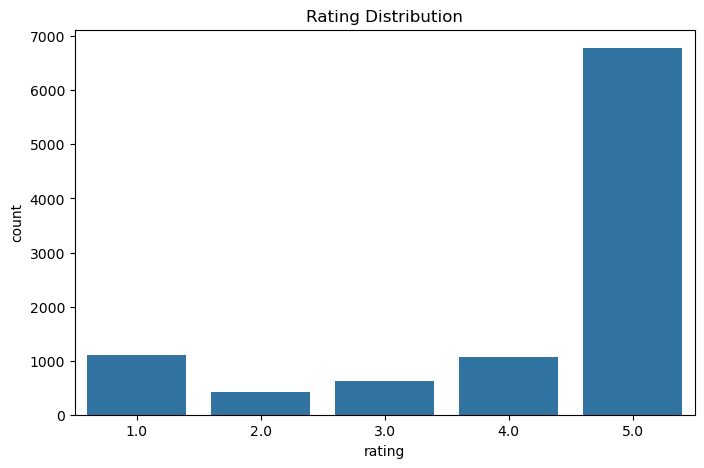

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(x='rating', data=sample_df)

plt.title("Rating Distribution")

plt.show()

In [25]:
sample_df["review_length"] = sample_df["text"].astype(str).apply(len)

sample_df[["text","review_length"]].head()

,text,review_length
0,Too expensive.,14
1,The steering cover makes my SUV stand out! I l...,53
2,Awesome,7
3,This Turn Signal Socket is just like the origi...,177
4,Update February 3 2023 : I have not had these ...,382


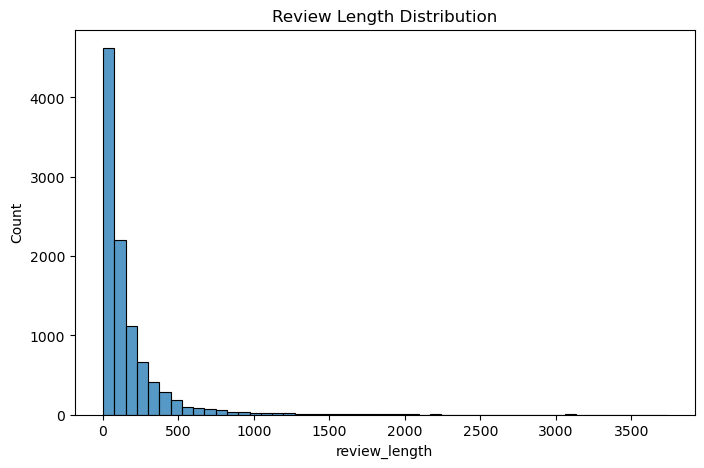

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(sample_df["review_length"], bins=50)

plt.title("Review Length Distribution")
plt.show()

In [27]:
sample_df.groupby("rating")["review_length"].mean()

rating
1.0    186.645627
2.0    254.923628
3.0    238.483254
4.0    205.333647
5.0    136.081846
Name: review_length, dtype: float64

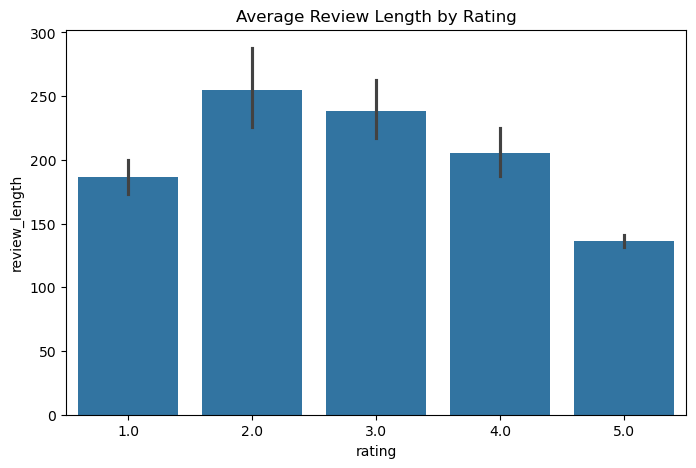

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="rating",
    y="review_length",
    data=sample_df
)

plt.title("Average Review Length by Rating")
plt.show()

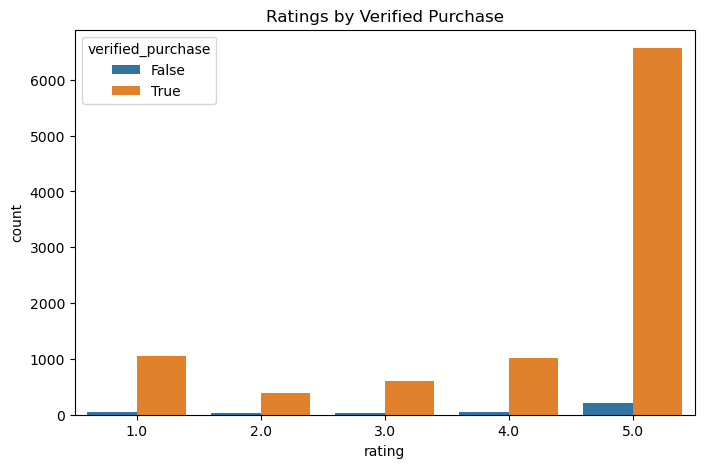

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="rating",
    hue="verified_purchase",
    data=sample_df
)

plt.title("Ratings by Verified Purchase")
plt.show()

In [30]:
sample_df["helpful_vote"].describe()

count    10000.000000
mean         0.700200
std          8.466126
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        748.000000
Name: helpful_vote, dtype: float64

In [31]:
sample_df.sort_values(
    by="helpful_vote",
    ascending=False
).head(10)

,rating,title,text,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_length
5150,5.0,As Advertised.,"I washed my car, clayed, polishing compound, c...",B08VRV42VT,AHSNQKPSO4FAAXQ44KT67Z54FS2Q,1511080397917,748,True,684
9401,5.0,Check With Seller For Fit Before Ordering,UPDATED REVIEW AND RATING:<br /><br />This cov...,B0BTZQ6CZ8,AHB7AOKW4QERAWDSXOURS4FZINUQ,1599001587234,233,True,1015
9389,5.0,LISTEN UP PEOPLE!!!!,Some people complained it will not charge a to...,B0009IBJE4,AEKQ42WAV5MWJEXY53VBCX2UZOJQ,1433439156000,170,True,1064
6244,3.0,It will work if you're handy enough to fix its...,I purchased this product because I wanted a lo...,B017S3MLHG,AEAA6VBYJFKULGDSUXM3LBSRAFMQ,1460150740000,109,True,2914
7299,5.0,"Best product I've tried, so good it made me ac...",My truck was completely covered in orange spec...,B004UM6DLE,AFPBA6266US4SKFBSDOXCXAJTMUQ,1466741573000,99,True,1106
9864,5.0,Fit's HONDA PILOT 2016,The Application guide says that this item does...,B0BYN3ZM8G,AGPFJXLOJXPA4PFVQCE3SMTV35PQ,1444089655000,89,True,232
1593,3.0,Will not start F250 Diesel truck more than one,Purchased top charge diesel truck batteries it...,B07BLP573M,AG7V3VNV3RKHQ5RLPCR65T6B67TQ,1570900162800,50,True,221
8541,4.0,Good device.,The first time I used the device reported an i...,B01M0ARG3X,AER37MA46XAI4DV7HBJ63KVNVVGQ,1535545582348,44,True,653
7208,5.0,Great on Tesla Model 3,This product works great on Tesla vegan leathe...,B00REX3LFM,AE3OEBKPXLVO52TAEM2DLU2KCC7Q,1537972163758,42,True,225
2010,5.0,2016 Colorado Crew Cab-Great Fit and Finish,"Plenty of positive reviews on this item, and I...",B07KFPLQHX,AELIGAZSH5PLG4HI4EB7GNIPP6RA,1483731846000,40,True,2075


In [32]:
sample_df["parent_asin"].value_counts().head(10)

parent_asin
B01LWDCSIZ    12
B0C6GZLBNV    10
B0C7CZXBBT    10
B000CITK8S     8
B09HZ3W89W     8
B00BYH6C1E     8
B0BND4VNHC     8
B0101SLT7S     7
B092R36QFD     6
B01D42TYFC     6
Name: count, dtype: int64

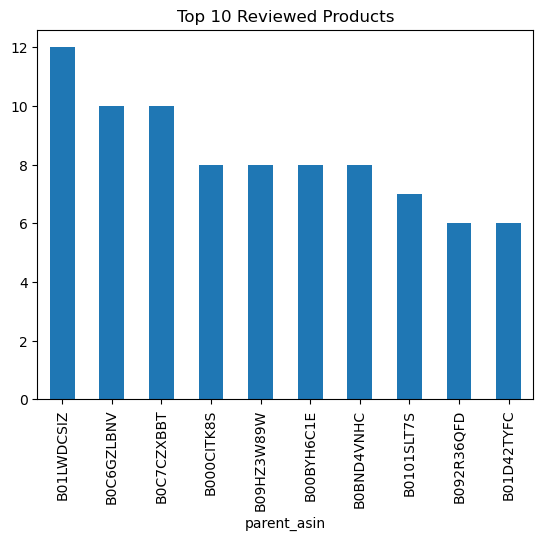

In [33]:
sample_df["parent_asin"] \
    .value_counts() \
    .head(10) \
    .plot(kind="bar")

plt.title("Top 10 Reviewed Products")
plt.show()

In [34]:
def sentiment(r):
    if r >= 4:
        return "Positive"
    elif r == 3:
        return "Neutral"
    else:
        return "Negative"

sample_df["sentiment"] = sample_df["rating"].apply(sentiment)

sample_df["sentiment"].value_counts()

sentiment
Positive    7845
Negative    1528
Neutral      627
Name: count, dtype: int64

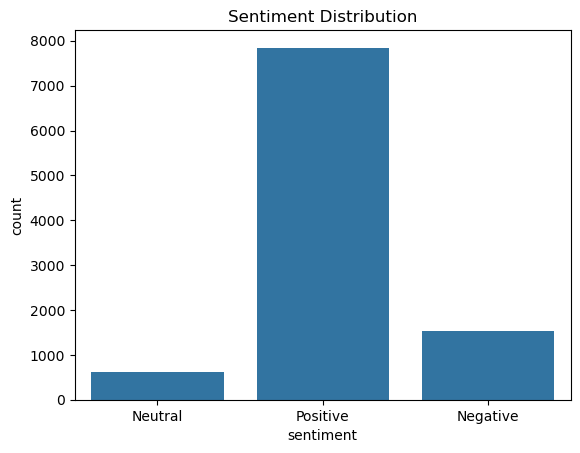

In [35]:
sns.countplot(
    x="sentiment",
    data=sample_df
)

plt.title("Sentiment Distribution")
plt.show()

In [36]:
sample_df["clean_text"] = (
    sample_df["text"]
    .str.lower()
)

In [37]:
import re

sample_df["clean_text"] = sample_df["clean_text"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", str(x))
)

In [38]:
!pip install wordcloud

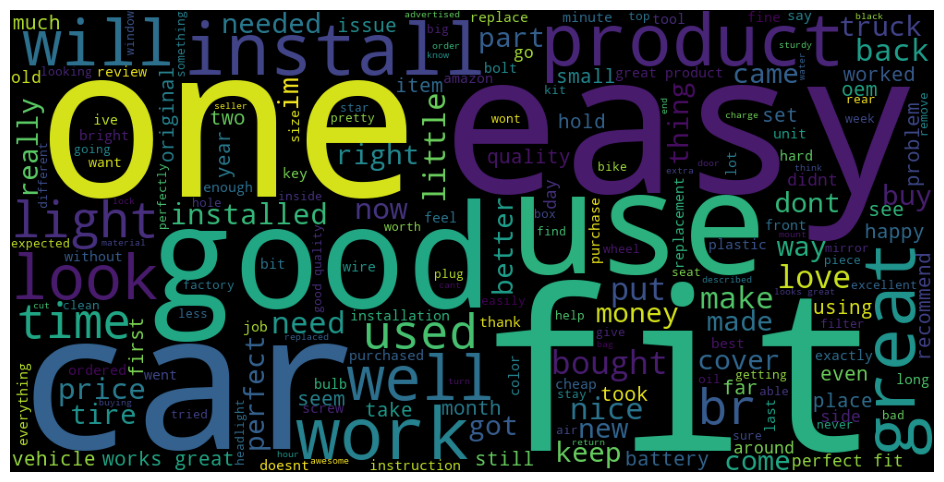

In [39]:
from wordcloud import WordCloud

text = " ".join(sample_df["clean_text"])

wc = WordCloud(
    width=1000,
    height=500
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [40]:
sample_df["title_length"] = sample_df["title"].astype(str).apply(len)

sample_df["review_word_count"] = (
    sample_df["text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

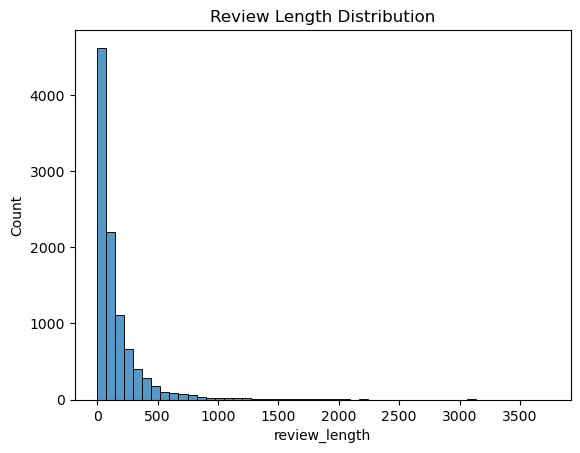

In [41]:
sample_df["review_length"] = sample_df["text"].astype(str).apply(len)

sns.histplot(sample_df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.show()

In [42]:
top_rated = meta_df[
    ["title", "average_rating", "rating_number"]
].sort_values(
    by="average_rating",
    ascending=False
)

top_rated.head(10)

,title,average_rating,rating_number
0,Caltric 3 Pack Oil Filter Compatible with Suzu...,5.0,1
12188,Hex Autoparts Windshield Wiper Arm Blade repla...,5.0,2
36460,Truck-Lite (94926) Stop/Turn/Tail Plug,5.0,3
36458,Willie and Max Double Down Tool Pouch - Brown,5.0,1
36455,Caravanture Trailer Jack Block Stand for RV Ca...,5.0,1
12167,Moog Chassis Parts 09 3010 101 Ball Joint,5.0,1
36451,OE Aftermarket Power Window Motor,5.0,4
36444,LaRosa Harley-Davidson Sportster XL Iron 883 N...,5.0,4
36443,ScorpionEXO Force Men's Street Motorcycle Jack...,5.0,4
36442,Bfgoodrich MUD TERRAIN T/A KM2 All Terrain Rad...,5.0,9


In [43]:
top_rated = meta_df[
    meta_df["rating_number"] > 100
].sort_values(
    by="average_rating",
    ascending=False
)

top_rated[
    ["title", "average_rating", "rating_number"]
].head(10)

,title,average_rating,rating_number
9079,Royal Purple 01512 Set of 4 Synchromax Manual ...,5.0,105
23879,Atomic Market Epoxy Filled Jehovah's Witness N...,4.9,119
38570,Diode Dynamics SS3 LED Fog Light Kit compatibl...,4.9,179
6777,3M Performance Gravity HVLP Atomizing Head Ref...,4.9,163
46382,"Cathedral Art Heart Visor Clip, Daughter",4.9,132
32715,LLI Toyoda | Decal Vinyl Sticker | Cars Trucks...,4.9,106
28569,Pro America Anti Biden Political Bumper Sticke...,4.9,281
1715,Red Line (50204-12PK) SAE 75W80 API GL-4 Manua...,4.9,808
35709,Valvoline VR1 Racing SAE 50 High Performance H...,4.9,5857
26064,"Car Window Shade for Baby,2023 Breathable Car ...",4.9,107
